# Simulations to examine how concentration index is influenced when GWAS attention is driven by High SDI disease burden

In [ ]:
library(here)
library(dplyr)
library(data.table)
library(rineq)
library(ggplot2)
library(ggstance)

get_ci <- function(x) {
  out <- ci(
    ineqvar = x$total_attention_score,
    outcome = x$val, method = "direct"
  )
  l <- tibble(
    ci = out$concentration_index,
    ci_se = sqrt(out$variance),
    ci_lci = ci - 1.96 * ci_se,
    ci_uci = ci + 1.96 * ci_se,
    daly_sum = sum(x$val, na.rm=TRUE)
  )
  l
}

generate_gwas_attention <- function(daly, rsq) {
    var_daly <- var(daly, na.rm=TRUE)
    sigma <- sqrt(var_daly)
    var_noise <- var_daly * (1 - rsq) / rsq
    gwas <- scale(daly + rnorm(length(daly), mean = 0, sd = sqrt(var_noise)))[,1]
    # logit <- function(p) log(p / (1 - p))
    # mu <- sqrt(1 + (pi^2 / 3) * sigma^2) * logit(p)
    # index <- rbinom(length(daly), 1, plogis(mu + scale(daly)))
    # print(prop.table(table(index)))
    # gwas[index == 0] <- 0
    gwas
}


In [118]:
d <- runif(10000)

cor(generate_gwas_attention(daly = d, rsq = 0.5), d)

[1] 0.7079397

In [119]:
gbd <- fread(here("Data/december2025/gbd_gwas_paper_data_3.csv")) %>% 
    filter(age_group_name == "All Ages", sex_id == 3, grepl("SDI", location_name))
gbd$location_name <- factor(gbd$location_name, levels = c(
  "High SDI", "High-middle SDI", "Middle SDI",
  "Low-middle SDI", "Low SDI", "Global"
))


For every year starting 2005 generate a GWAS attention score using the DALY from high SDI 3 years prior.

Then calculate the CI for each SDI group and each year

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


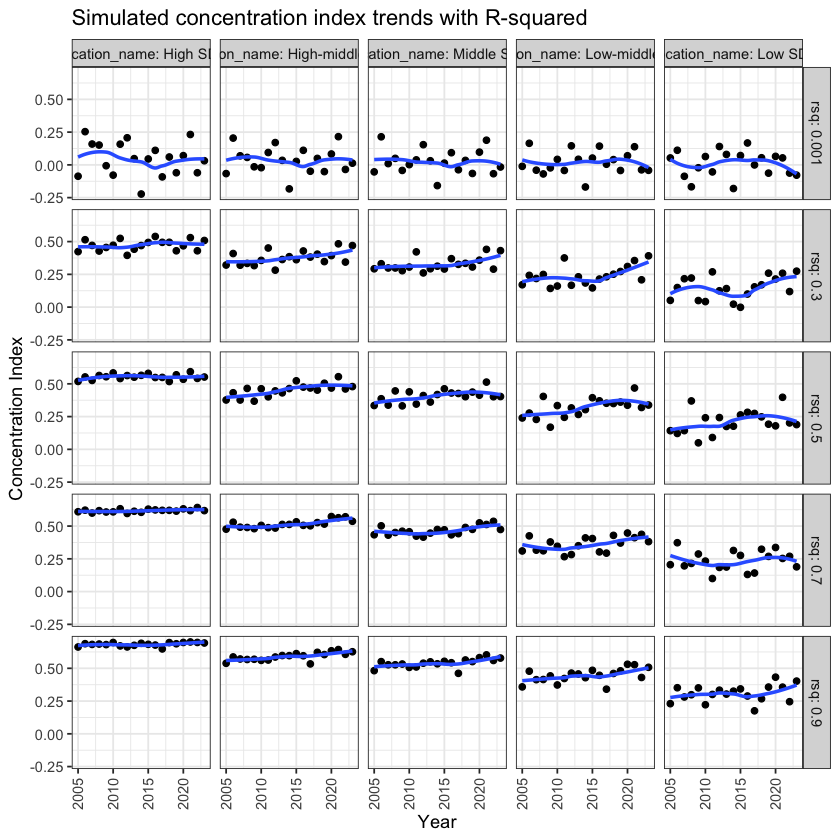

In [120]:
simulation <- function(gbd, rsq) {

    gwas <- gbd %>%
        filter(location_name == "High SDI") %>%
        group_by(year_id) %>%
        mutate(total_attention_score = generate_gwas_attention(daly = val, rsq = rsq)) %>%
        select(gbd_year = year_id, cause_name, total_attention_score, input_val = val) %>%
        mutate(year_id = gbd_year)
    
    dat <- inner_join(gbd, gwas, by = c("cause_name", "year_id")) %>%
        group_by(location_name, year_id) %>%
        do(get_ci(.)) %>%
        filter(year_id >= 2005, year_id <= 2024) %>%
        mutate(rsq = rsq)
    dat
}

lapply(c(0.001, 0.3, 0.5, 0.7, 0.9), function(rsq) {
    simulation(gbd, rsq)
}) %>% bind_rows() %>%
    ggplot(., aes(x=year_id, y=ci)) +
        geom_point() +
        geom_smooth(se=FALSE) +
        facet_grid(rsq~location_name, labeller = label_both) +
        theme_bw() +
        labs(x = "Year", y = "Concentration Index", title = "Simulated concentration index trends with R-squared") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = "none")

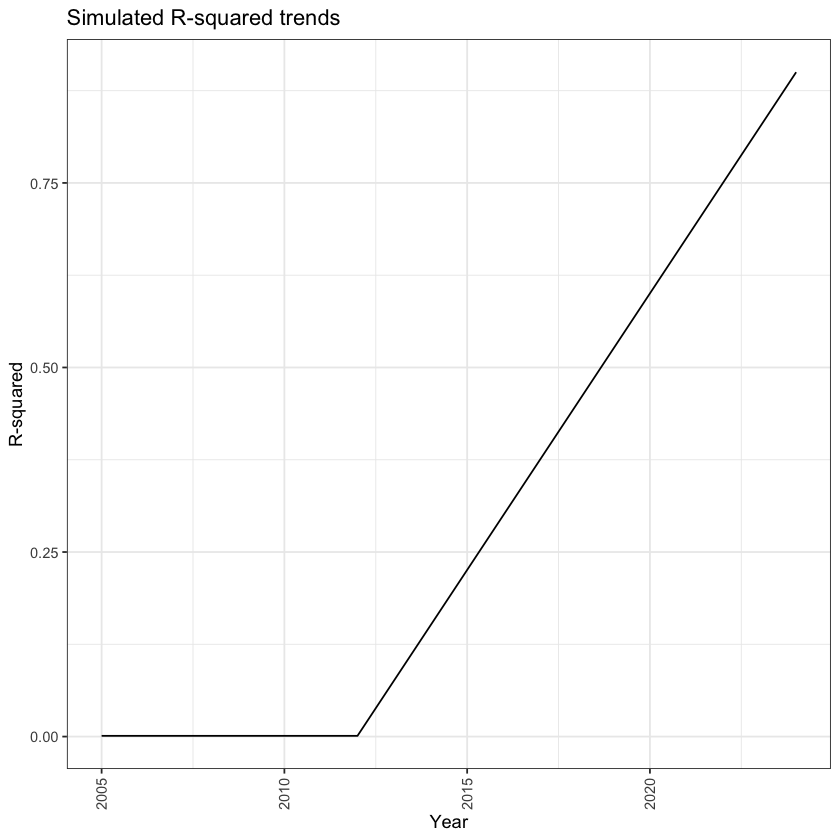

In [90]:
generate_rsq <- function(param1, param2) {
    bind_rows(
        tibble(year = 2005:2012, rsq = param1),
        tibble(year = 2013:2024, rsq = approx(c(2012, 2024), c(param1, param2), xout = 2013:2024)$y)
    )
}
generate_rsq(0.01, 0.9) %>%
    ggplot(aes(x=year, y=rsq)) +
        geom_line() +
        theme_bw() +
        labs(x = "Year", y = "R-squared", title = "Simulated R-squared trends") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = "none")

Warning message:
“There were 15 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 1990`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 14 remaining warnings.”
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


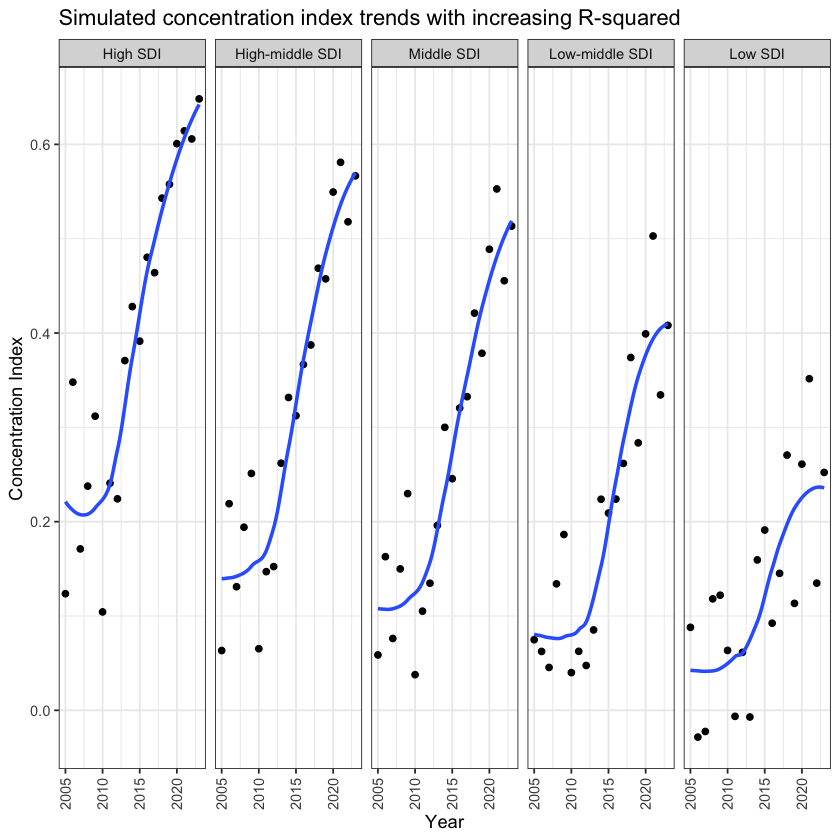

In [284]:
simulation <- function(gbd, param1, param2) {

    rsq_trend <- generate_rsq(param1, param2)
    gwas <- gbd %>%
        filter(location_name == "High SDI") %>%
        group_by(year_id) %>%
        mutate(total_attention_score = generate_gwas_attention(daly = val, rsq = rsq_trend$rsq[match(year_id, rsq_trend$year)])) %>%
        select(gbd_year = year_id, cause_name, total_attention_score, input_val = val) %>%
        mutate(year_id = gbd_year)
    
    dat <- inner_join(gbd, gwas, by = c("cause_name", "year_id")) %>%
        group_by(location_name, year_id) %>%
        do(get_ci(.)) %>%
        filter(year_id >= 2005, year_id <= 2024) %>%
        inner_join(rsq_trend, by = c("year_id" = "year"))
    dat
}
dat <- simulation(gbd, 0.01, 0.8)
dat %>%
    ggplot(aes(x=year_id, y=ci)) +
        geom_point() +
        geom_smooth(se=FALSE) +
        facet_grid(. ~ location_name) +
        theme_bw() +
        labs(x = "Year", y = "Concentration Index", title = "Simulated concentration index trends with increasing R-squared") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = "none")

In [99]:
res <- lapply(1:100, \(i) {
    simulation(gbd, 0.01, 0.8) %>% mutate(sim = i)
}) %>% bind_rows()

Warning message:
“There were 15 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 1990`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 14 remaining warnings.”
Warning message:
“There were 15 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 1990`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 14 remaining warnings.”
Warning message:
“There were 15 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 1990`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 14 remaining warnings.”
Warning message:
“There were 15 warnings in `mutate()`.
The first warning was:
ℹ In argument: `to

gropd_df [9,500 × 9] (S3: grouped_df/tbl_df/tbl/data.frame)
 $ location_name: Factor w/ 6 levels "High SDI","High-middle SDI",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ year_id      : int [1:9500] 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 ...
 $ ci           : num [1:9500] 0.2205 0.0578 0.0736 0.138 0.3126 ...
 $ ci_se        : num [1:9500] 0.1005 0.0924 0.0892 0.0503 0.0857 ...
 $ ci_lci       : num [1:9500] 0.0236 -0.1234 -0.1012 0.0394 0.1447 ...
 $ ci_uci       : num [1:9500] 0.417 0.239 0.248 0.237 0.48 ...
 $ daly_sum     : num [1:9500] 9.74e+08 9.69e+08 9.70e+08 9.72e+08 9.67e+08 ...
 $ rsq          : num [1:9500] 0.01 0.01 0.01 0.01 0.01 ...
 $ sim          : int [1:9500] 1 1 1 1 1 1 1 1 1 1 ...
 - attr(*, "groups")= tibble [95 × 3] (S3: tbl_df/tbl/data.frame)
  ..$ location_name: Factor w/ 6 levels "High SDI","High-middle SDI",..: 1 1 1 1 1 1 1 1 1 1 ...
  ..$ year_id      : int [1:95] 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 ...
  ..$ .rows        : list<int> [1:95] 
  .

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by location_name and year_id.
ℹ Output is grouped by location_name.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(location_name, year_id))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


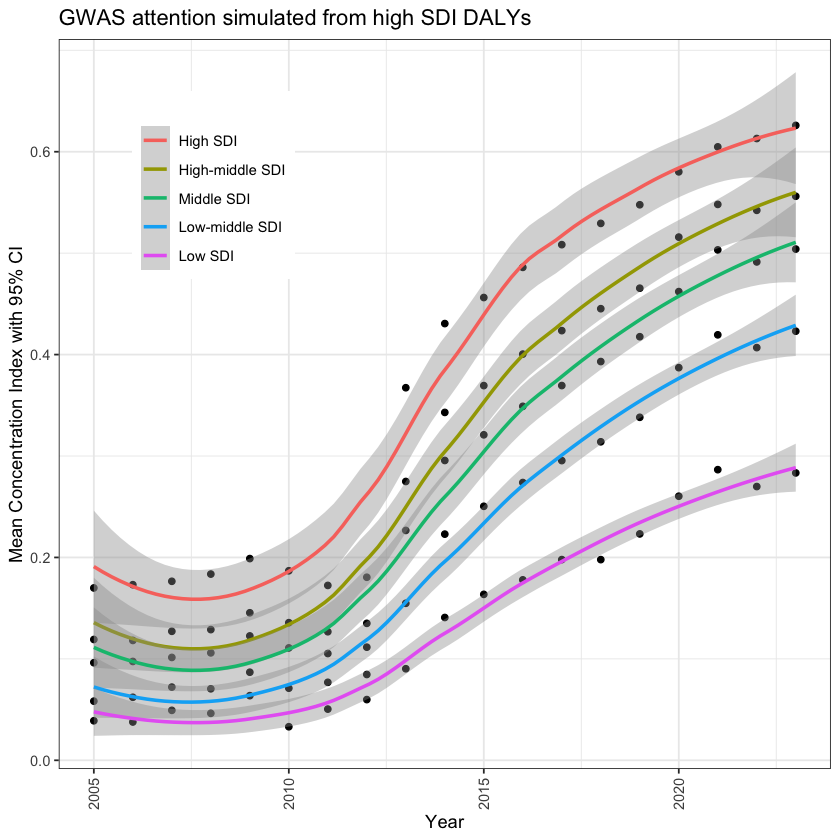

In [111]:
str(res)
res %>% group_by(location_name, year_id) %>%
    summarise(ci_mean = mean(ci), ci_lci = mean(ci_lci), ci_uci = mean(ci_uci)) %>%
    ggplot(aes(x=year_id, y=ci_mean)) +
        geom_point() +
        geom_smooth(aes(colour = location_name)) +
        theme_bw() +
        labs(x = "Year", y = "Mean Concentration Index with 95% CI", title = "GWAS attention simulated from high SDI DALYs", colour="") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = c(0.2, 0.8))
ggsave(here("figures/simulation_ci_trends.png"), width = 8, height = 8)

In [112]:
gwas_attention <- fread(here("Data/merged_dataset_exclude_Injuries_2023_updated_5.csv"))
str(gwas_attention)

Classes ‘data.table’ and 'data.frame':	4743 obs. of  5 variables:
 $ cause_name           : chr  "Acne vulgaris" "Acne vulgaris" "Acne vulgaris" "Acne vulgaris" ...
 $ cause_id             : int  661 661 661 661 661 661 661 661 661 661 ...
 $ total_attention_score: num  1296804 215 13909 13909 13694 ...
 $ analysis_type        : chr  "all" "sliding_3yr" "sliding_3yr" "sliding_3yr" ...
 $ time_strata          : int  NA 2011 2012 2013 2014 2016 2017 2018 2019 2020 ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [128]:
# List of all traits
all_traits <- sort(unique(gwas_attention[["cause_name"]]))

temp <- left_join(
    expand.grid(cause_name = all_traits, time_strata = 2005:2024, analysis_type = "sliding_3yr"),
    gwas_attention,
)
temp$total_attention_score[is.na(temp$total_attention_score)] <- 0
str(temp)


Joining with `by = join_by(cause_name, time_strata, analysis_type)`


'data.frame':	6240 obs. of  5 variables:
 $ cause_name           : chr  "Acne vulgaris" "Acute glomerulonephritis" "Acute hepatitis" "Acute hepatitis A" ...
 $ time_strata          : int  2005 2005 2005 2005 2005 2005 2005 2005 2005 2005 ...
 $ analysis_type        : chr  "sliding_3yr" "sliding_3yr" "sliding_3yr" "sliding_3yr" ...
 $ cause_id             : int  NA NA NA NA NA NA NA NA NA NA ...
 $ total_attention_score: num  0 0 0 0 0 0 0 0 0 0 ...
 - attr(*, "out.attrs")=List of 2
  ..$ dim     : Named int [1:3] 312 20 1
  .. ..- attr(*, "names")= chr [1:3] "cause_name" "time_strata" "analysis_type"
  ..$ dimnames:List of 3
  .. ..$ cause_name   : chr [1:312] "cause_name=Acne vulgaris" "cause_name=Acute glomerulonephritis" "cause_name=Acute hepatitis" "cause_name=Acute hepatitis A" ...
  .. ..$ time_strata  : chr [1:20] "time_strata=2005" "time_strata=2006" "time_strata=2007" "time_strata=2008" ...
  .. ..$ analysis_type: chr "analysis_type=sliding_3yr"


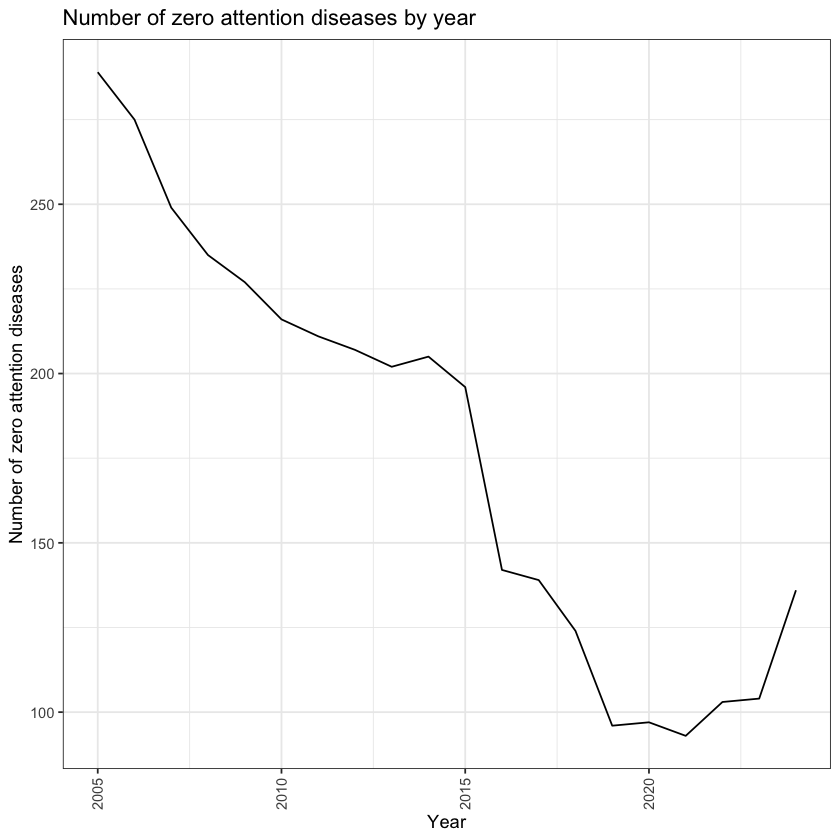

In [129]:
# Number of zero attention scores by year
temp %>%
    group_by(time_strata) %>%
    summarise(num_zero_attention = sum(total_attention_score == 0)) %>% 
    ggplot(., aes(x = time_strata, y = num_zero_attention)) +
        geom_line() +
        theme_bw() +
        labs(x = "Year", y = "Number of zero attention diseases", title = "Number of zero attention diseases by year") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = "none")

In [261]:
length(unique(gbd$cause_name))

[1] 309

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


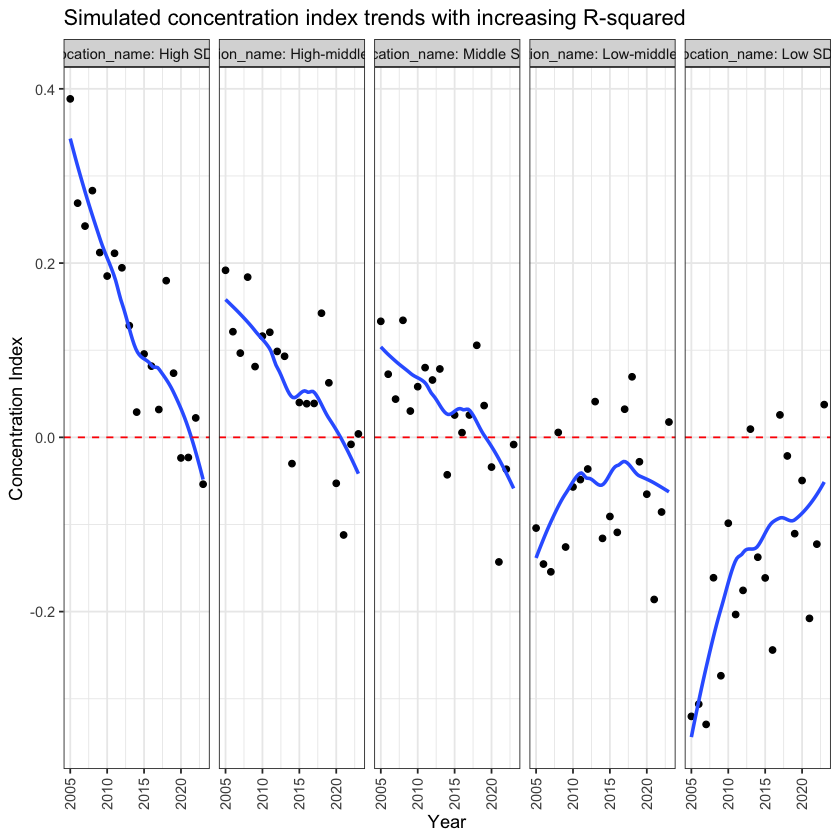

In [270]:
generate_gwas_attention <- function(daly, rsq, nzero = 0) {
    
    zero_indices <- 1:length(daly) %in% sample(length(daly), nzero)
    var_daly <- var(daly[zero_indices], na.rm=TRUE)
    sigma <- sqrt(var_daly)
    var_noise <- var_daly * (1 - rsq) / rsq
    gwas <- scale(daly + rnorm(length(daly), mean = 0, sd = sqrt(var_noise)))[,1]
    min_gwas <- min(gwas)
    gwas <- gwas - min_gwas + 1
    gwas[zero_indices] <- 0
    gwas
}
set.seed(123)
generate_gwas_attention <- function(daly, rsq, nzero = 0) {

    zero_indices <- 1:length(daly) %in% sample(length(daly), nzero)
    gwas <- 10^rbeta(length(daly), shape1 = 2, shape2 = 5) * 100
    gwas[zero_indices] <- 0
    gwas
}

simulation <- function(gbd, param1, param2, nzero_start, nzero_end) {

    rsq_trend <- generate_rsq(param1, param2)
    rsq_trend$nzero <- round(approx(c(2005, 2024), c(nzero_start, nzero_end), xout = 2005:2024)$y)
    gwas <- gbd %>%
        filter(location_name == "High SDI", year_id >= 2005, year_id <= 2024) %>%
        group_by(year_id) %>%
        mutate(total_attention_score = generate_gwas_attention(daly = val, rsq = rsq_trend$rsq[match(year_id[1], rsq_trend$year)], nzero = rsq_trend$nzero[match(year_id[1], rsq_trend$year)])) %>%
        select(gbd_year = year_id, cause_name, total_attention_score, input_val = val) %>%
        mutate(year_id = gbd_year, nzero = rsq_trend$nzero[match(year_id[1], rsq_trend$year)], rsq = rsq_trend$rsq[match(year_id[1], rsq_trend$year)])
    
    dat <- inner_join(gbd, gwas, by = c("cause_name", "year_id")) %>%
        group_by(location_name, year_id) %>%
        do(get_ci(.)) %>%
        filter(year_id >= 2005, year_id <= 2024) %>%
        inner_join(rsq_trend, by = c("year_id" = "year"))
    dat
}
dat <- simulation(gbd, 0.99, 0.99, 306, 100)
# str(dat)
dat %>%
    ggplot(aes(x=year_id, y=ci)) +
        geom_point() +
        geom_smooth(se=FALSE) +
        facet_grid(. ~ location_name, labeller = label_both) +
        theme_bw() +
        labs(x = "Year", y = "Concentration Index", title = "Simulated concentration index trends with increasing R-squared") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = "none") +
        geom_hline(yintercept = 0, linetype = "dashed", color = "red")

In [238]:
rzipois <- function (n, lambda, zi.prob) {
  Y <- rpois(n, lambda)
  U <- rbinom(n, 1, plogis(Y))
  U*Y }
x <- rnorm(1000, mean = 5)
lambda <- plogis(x)
y <- rzipois(1000, lambda = lambda, zi.prob = 0.6)
table(y == 0) %>% prop.table()
cor(y, x)



FALSE  TRUE 
0.257 0.743 

[1] 0.0947556

In [248]:
res <- lapply(1:100, \(i) {
    simulation(gbd, 0, 0, 275, 100) %>% mutate(sim = i)
}) %>% bind_rows()

Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 2005`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 18 remaining warnings.”
Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 2005`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 18 remaining warnings.”
Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `total_attention_score = generate_gwas_attention(...)`.
ℹ In group 1: `year_id = 2005`.
Caused by warning in `rnorm()`:
! NAs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 18 remaining warnings.”
Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `to

gropd_df [9,500 × 10] (S3: grouped_df/tbl_df/tbl/data.frame)
 $ location_name: Factor w/ 6 levels "High SDI","High-middle SDI",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ year_id      : int [1:9500] 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 ...
 $ ci           : num [1:9500] 0.311 0.366 0.327 0.255 0.299 ...
 $ ci_se        : num [1:9500] 0.123 0.123 0.126 0.125 0.122 ...
 $ ci_lci       : num [1:9500] 0.0704 0.1249 0.0797 0.011 0.059 ...
 $ ci_uci       : num [1:9500] 0.552 0.607 0.574 0.499 0.538 ...
 $ daly_sum     : num [1:9500] 9.74e+08 9.69e+08 9.70e+08 9.72e+08 9.67e+08 ...
 $ rsq          : num [1:9500] 0 0 0 0 0 0 0 0 0 0 ...
 $ nzero        : num [1:9500] 275 266 257 247 238 229 220 211 201 192 ...
 $ sim          : int [1:9500] 1 1 1 1 1 1 1 1 1 1 ...
 - attr(*, "groups")= tibble [95 × 3] (S3: tbl_df/tbl/data.frame)
  ..$ location_name: Factor w/ 6 levels "High SDI","High-middle SDI",..: 1 1 1 1 1 1 1 1 1 1 ...
  ..$ year_id      : int [1:95] 2005 2006 2007 2008 2009 2010 2011 20

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by location_name and year_id.
ℹ Output is grouped by location_name.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(location_name, year_id))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


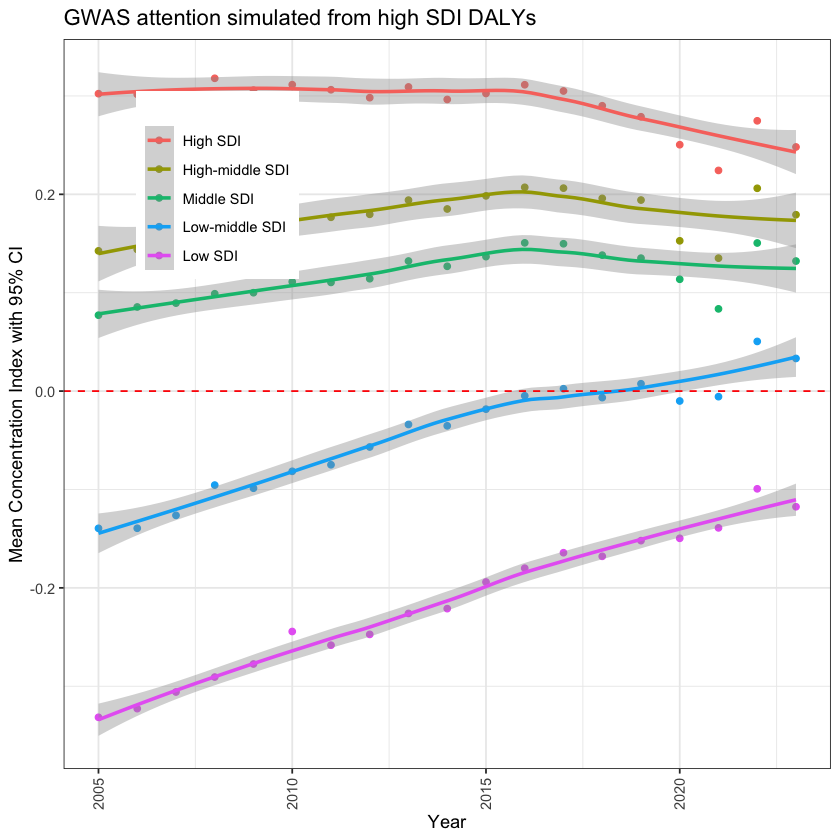

In [249]:
str(res)
res %>% group_by(location_name, year_id) %>%
    summarise(ci_mean = mean(ci), ci_lci = mean(ci_lci), ci_uci = mean(ci_uci)) %>%
    ggplot(aes(x=year_id, y=ci_mean)) +
        geom_point(aes(colour = location_name)) +
        geom_smooth(aes(colour = location_name)) +
        theme_bw() +
        labs(x = "Year", y = "Mean Concentration Index with 95% CI", title = "GWAS attention simulated from high SDI DALYs", colour="") +
        theme(axis.text.x = element_text(angle=90, vjust=0.5, hjust = 1), legend.position = c(0.2, 0.8)) +
        geom_hline(yintercept = 0, linetype = "dashed", color = "red")
ggsave(here("figures/simulation_ci_trends2.png"), width = 8, height = 8)

Classes ‘data.table’ and 'data.frame':	4743 obs. of  5 variables:
 $ cause_name           : chr  "Acne vulgaris" "Acne vulgaris" "Acne vulgaris" "Acne vulgaris" ...
 $ cause_id             : int  661 661 661 661 661 661 661 661 661 661 ...
 $ total_attention_score: num  1296804 215 13909 13909 13694 ...
 $ analysis_type        : chr  "all" "sliding_3yr" "sliding_3yr" "sliding_3yr" ...
 $ time_strata          : int  NA 2011 2012 2013 2014 2016 2017 2018 2019 2020 ...
 - attr(*, ".internal.selfref")=<externalptr> 


time_strata,num_zero_attention,n
<int>,<int>,<int>
2005,289,312
2006,275,312
2007,249,312
2008,235,312
2009,227,312
2010,216,312
2011,211,312
2012,207,312
2013,202,312


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


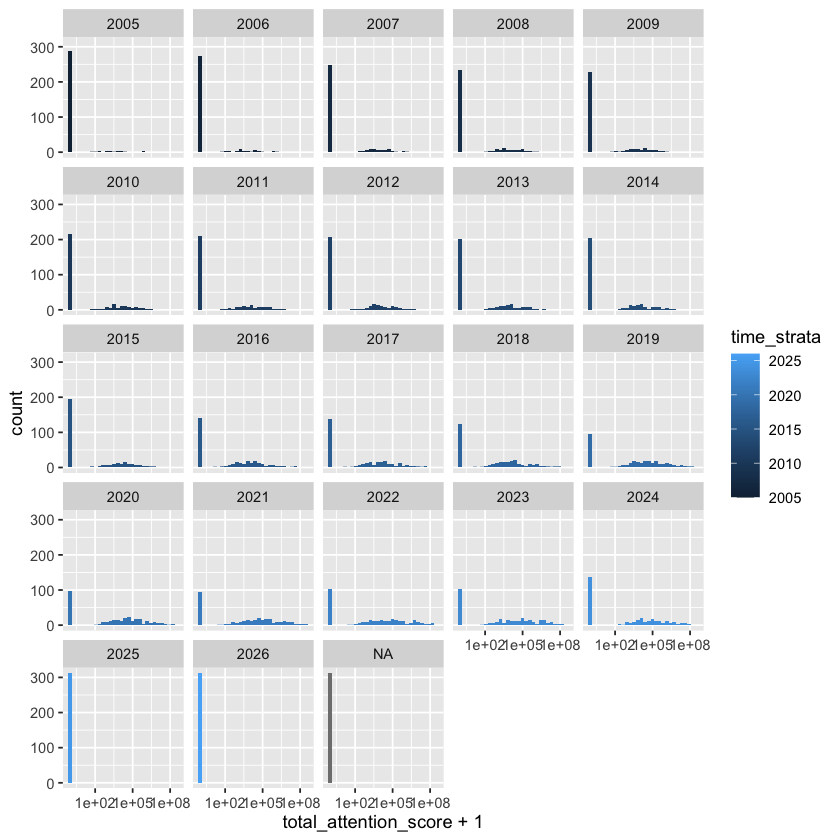

In [282]:
str(gwas_attention)


pad_zero <- function(gwas_attention) {
    allgwas <- unique(gwas_attention$cause_name)
  temp1 <- subset(gwas_attention, analysis_type == "sliding_3yr")
  temp2 <- subset(gwas_attention, analysis_type == "all")
  temp3 <- left_join(
    expand.grid(cause_name = allgwas, time_strata = unique(gwas_attention$time_strata)),
    temp1, by = c("cause_name", "time_strata")
  ) %>%
    mutate(total_attention_score = case_when(is.na(total_attention_score) ~ 0, TRUE ~ total_attention_score), analysis_type = "sliding_3yr")
  bind_rows(temp3, temp2)
}

pad_zero(gwas_attention) %>% filter(analysis_type == "sliding_3yr") %>% group_by(time_strata) %>% summarise(num_zero_attention = sum(total_attention_score == 0), n=n())

ggplot(gwas_attention %>% pad_zero() %>% filter(analysis_type == "sliding_3yr"), aes(x = total_attention_score+1)) +
geom_histogram(aes(fill=time_strata)) +
facet_wrap(~ time_strata) +
scale_x_log10()


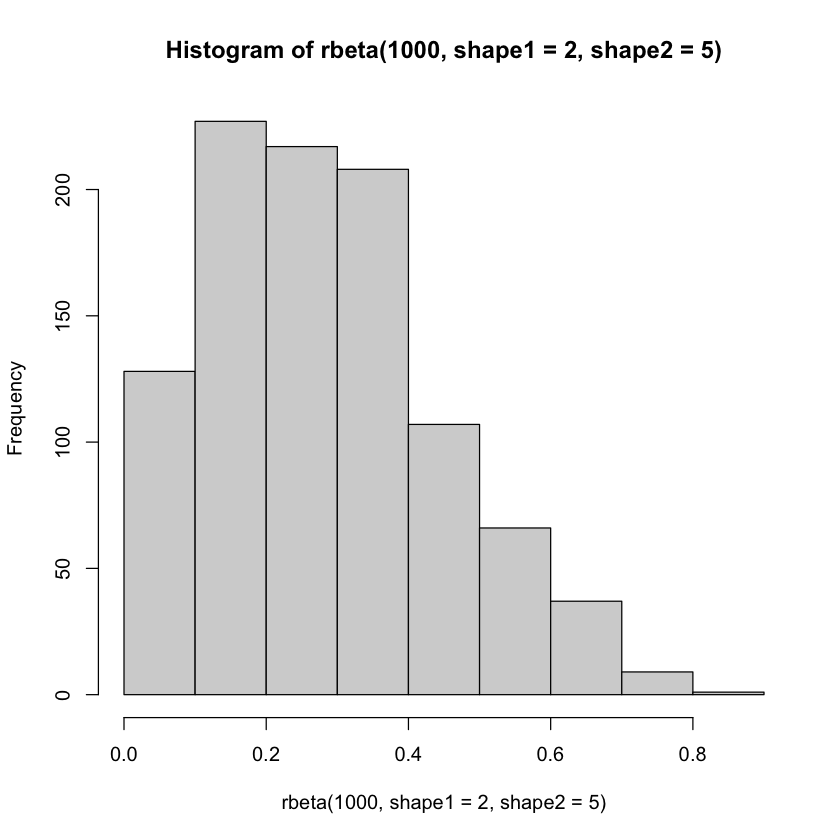

In [259]:
hist(rbeta(1000, shape1 = 2, shape2 = 5))